# 데이터 로드 및 전처리 & 확인

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

# 로드
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
                'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# 정규화 + 채널 차원 추가 (CNN용)
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test  = X_test.reshape(-1, 28, 28, 1)  / 255.0

# 원-핫 인코딩
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test,  10)

I0000 00:00:1775094279.813163    2917 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775094280.807885    2917 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775094283.479214    2917 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


=== 데이터 shape ===
X_train: (60000, 28, 28, 1)
X_test : (10000, 28, 28, 1)
y_train: (60000,)
y_test : (10000,)

=== 픽셀값 범위 ===
X_train min: 0.0, max: 1.0
X_test  min: 0.0,  max: 1.0

=== 클래스별 샘플 수 (train) ===
  0 T-shirt     : 6000장
  1 Trouser     : 6000장
  2 Pullover    : 6000장
  3 Dress       : 6000장
  4 Coat        : 6000장
  5 Sandal      : 6000장
  6 Shirt       : 6000장
  7 Sneaker     : 6000장
  8 Bag         : 6000장
  9 Ankle boot  : 6000장


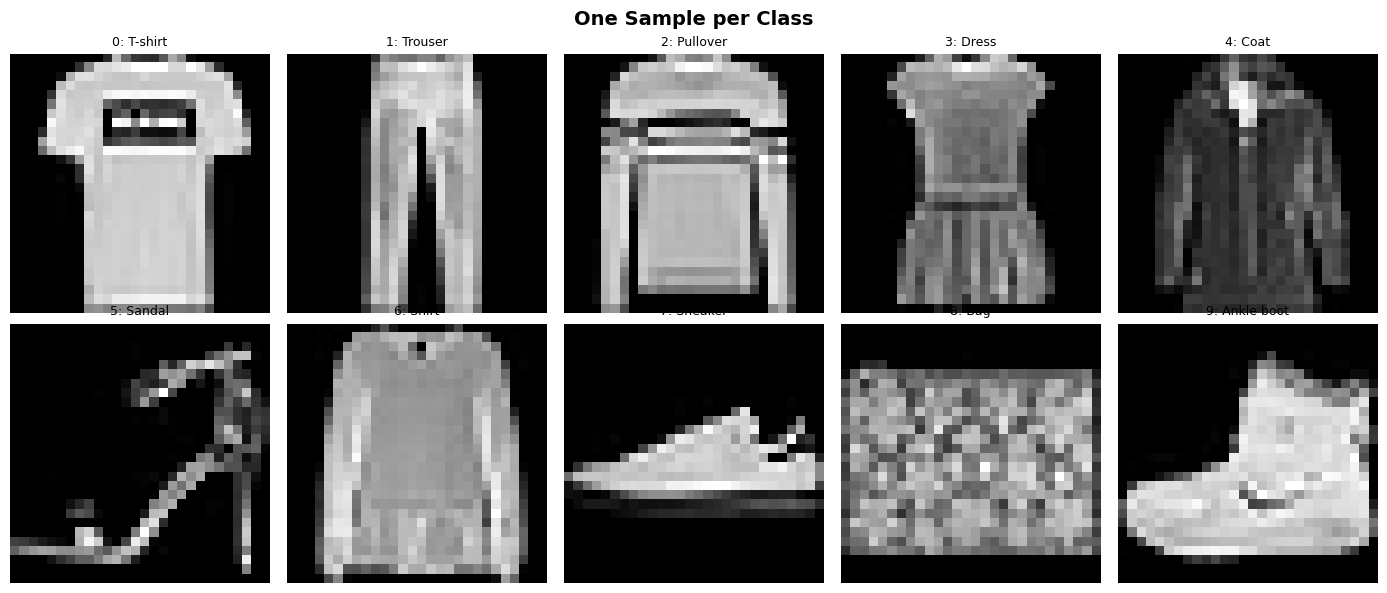

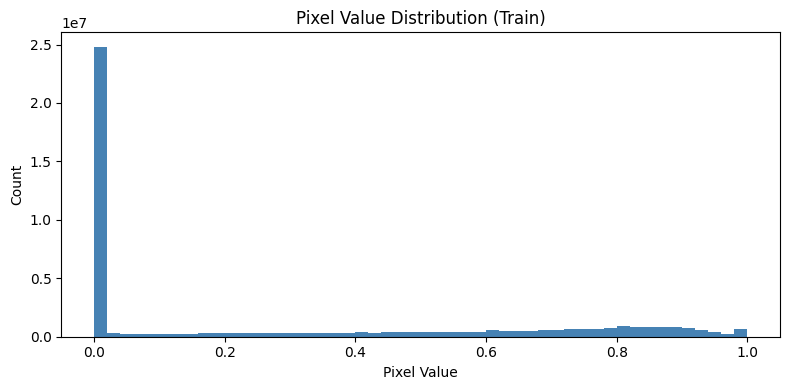

In [3]:
# ── 기본 정보 확인 ──────────────────────────────────────────
print("=== 데이터 shape ===")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

print("\n=== 픽셀값 범위 ===")
print(f"X_train min: {X_train.min():.1f}, max: {X_train.max():.1f}")
print(f"X_test  min: {X_test.min():.1f},  max: {X_test.max():.1f}")

print("\n=== 클래스별 샘플 수 (train) ===")
for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    print(f"  {i} {name:12s}: {count}장")


# ── 클래스별 대표 이미지 1장씩 ─────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("One Sample per Class", fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    idx = np.where(y_train == i)[0][0]
    ax.imshow(X_train[idx].squeeze(), cmap='gray')
    ax.set_title(f"{i}: {class_names[i]}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

# ── 픽셀값 분포 히스토그램 ─────────────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(X_train.flatten(), bins=50, color='steelblue', edgecolor='none')
plt.title("Pixel Value Distribution (Train)")
plt.xlabel("Pixel Value")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

- 검은 배경에 흰 아이템 구조 > 배경인 검은 픽셀(값=0)이 전체의 대부분을 차지. 실제로 옷이나 신발이 차지하는 영역은 일부분 / 나머지는 다 검은 배경
- 0.6~1.0 구간에 낮게 퍼져있는 부분이 실제 아이템 픽셀값: 높을수록 밝은 픽셀, 즉 옷의 실루엣에 해당
> 정리하면 "대부분의 픽셀은 배경(검정=0)이고, 소수의 픽셀만 실제 패션 아이템을 나타낸다"라는 Fashion MNIST 데이터의 특성을 시각적으로 확인

# 기본 CNN 모델 정의 + 학습 + 테스트 평가

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 기본 CNN
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),  # 여기 값 바꿔가며 실습 가능
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = cnn_model.fit(
    X_train, y_train_cat,
    epochs=10,          # 여기 조정
    batch_size=128,     # 여기 조정
    validation_split=0.2,
    verbose=2
)

test_loss_cnn, test_acc_cnn = cnn_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"[기본 CNN] Test loss: {test_loss_cnn:.4f}, Test accuracy: {test_acc_cnn:.4f}")

/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1775027701.881852  127498 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/10


I0000 00:00:1775027705.897761  127595 service.cc:153] XLA service 0x78d858032ef0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775027705.897824  127595 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775027705.924458  127595 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775027706.124002  127595 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775027706.163210  127595 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1727__.35
I0000 00:00:1775027710.926908  127595 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 - 10s - 26ms/step - accuracy: 0.7919 - loss: 0.5854 - val_accuracy: 0.8661 - val_loss: 0.3668
Epoch 2/10
375/375 - 6s - 15ms/step - accuracy: 0.8716 - loss: 0.3636 - val_accuracy: 0.8910 - val_loss: 0.3037
Epoch 3/10
375/375 - 2s - 5ms/step - accuracy: 0.8866 - loss: 0.3133 - val_accuracy: 0.8978 - val_loss: 0.2776
Epoch 4/10
375/375 - 2s - 4ms/step - accuracy: 0.8983 - loss: 0.2831 - val_accuracy: 0.9038 - val_loss: 0.2625
Epoch 5/10
375/375 - 2s - 5ms/step - accuracy: 0.9045 - loss: 0.2620 - val_accuracy: 0.9039 - val_loss: 0.2597
Epoch 6/10
375/375 - 2s - 5ms/step - accuracy: 0.9106 - loss: 0.2429 - val_accuracy: 0.9078 - val_loss: 0.2436
Epoch 7/10
375/375 - 2s - 5ms/step - accuracy: 0.9179 - loss: 0.2263 - val_accuracy: 0.9162 - val_loss: 0.2288
Epoch 8/10
375/375 - 2s - 5ms/step - accuracy: 0.9204 - loss: 0.2120 - val_accuracy: 0.9123 - val_loss: 0.2393
Epoch 9/10
375/375 - 2s - 5ms/step - accuracy: 0.9271 - loss: 0.2016 - val_accuracy: 0.9206 - val_loss: 0.2191
Epoch 10/

# 기본 CNN 학습곡선 시각화

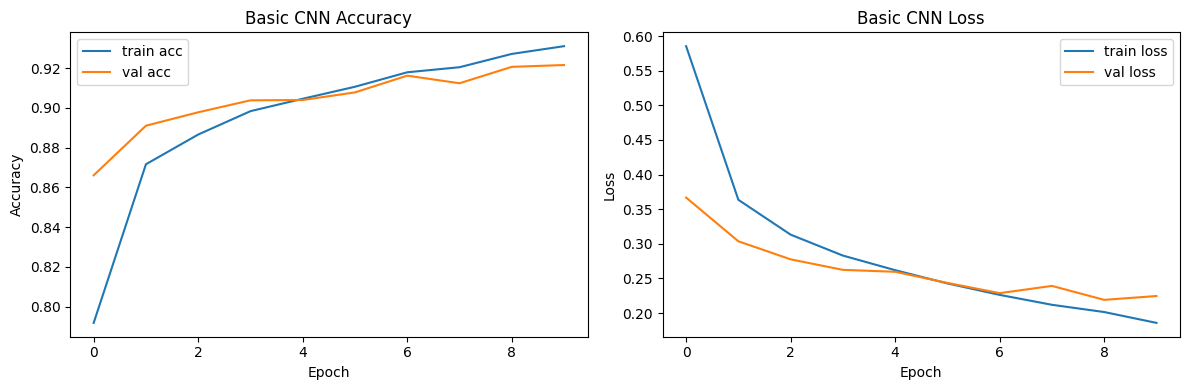

In [3]:
plt.figure(figsize=(12,4))

# 정확도
plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='train acc')
plt.plot(history_cnn.history['val_accuracy'], label='val acc')
plt.title('Basic CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 손실
plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='train loss')
plt.plot(history_cnn.history['val_loss'], label='val loss')
plt.title('Basic CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# DNN 모델 정의 + 학습 + 테스트 평가 (CNN 비교용)

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

dnn_model = Sequential([
    Flatten(input_shape=(28,28,1)),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

dnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),  # 조정 가능
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_dnn = dnn_model.fit(
    X_train, y_train_cat,
    epochs=10,          # 조정 가능
    batch_size=128,     # 조정 가능
    validation_split=0.2,
    verbose=2
)

test_loss_dnn, test_acc_dnn = dnn_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"[DNN] Test loss: {test_loss_dnn:.4f}, Test accuracy: {test_acc_dnn:.4f}")
print(f"[CNN] Test accuracy (ref): {test_acc_cnn:.4f}")
print(f"Accuracy gap (CNN - DNN): {test_acc_cnn - test_acc_dnn:+.4f}")

/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10


I0000 00:00:1775027739.688615  127598 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23757__.18
I0000 00:00:1775027739.807696  127598 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775027740.434832  128888 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1775027741.067449  127598 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775027741.447415  128887 subprocess_compilation.cc:348] ptxas warning : Registers are spille

375/375 - 7s - 20ms/step - accuracy: 0.7802 - loss: 0.6189 - val_accuracy: 0.8452 - val_loss: 0.4383
Epoch 2/10
375/375 - 2s - 5ms/step - accuracy: 0.8412 - loss: 0.4395 - val_accuracy: 0.8569 - val_loss: 0.3880
Epoch 3/10
375/375 - 2s - 6ms/step - accuracy: 0.8533 - loss: 0.4014 - val_accuracy: 0.8673 - val_loss: 0.3636
Epoch 4/10
375/375 - 5s - 14ms/step - accuracy: 0.8613 - loss: 0.3768 - val_accuracy: 0.8712 - val_loss: 0.3537
Epoch 5/10
375/375 - 2s - 5ms/step - accuracy: 0.8668 - loss: 0.3600 - val_accuracy: 0.8726 - val_loss: 0.3479
Epoch 6/10
375/375 - 2s - 6ms/step - accuracy: 0.8725 - loss: 0.3479 - val_accuracy: 0.8779 - val_loss: 0.3327
Epoch 7/10
375/375 - 2s - 6ms/step - accuracy: 0.8746 - loss: 0.3374 - val_accuracy: 0.8756 - val_loss: 0.3357
Epoch 8/10
375/375 - 2s - 6ms/step - accuracy: 0.8782 - loss: 0.3276 - val_accuracy: 0.8810 - val_loss: 0.3315
Epoch 9/10
375/375 - 2s - 6ms/step - accuracy: 0.8815 - loss: 0.3211 - val_accuracy: 0.8804 - val_loss: 0.3247
Epoch 10/1

# DNN vs CNN 학습곡선 비교 시각화

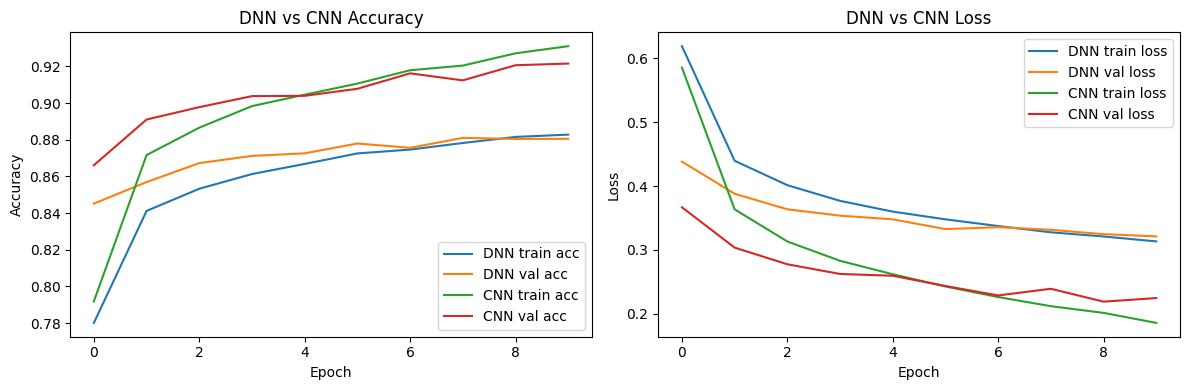

In [5]:
plt.figure(figsize=(12,4))

# 정확도 비교
plt.subplot(1,2,1)
plt.plot(history_dnn.history['accuracy'], label='DNN train acc')
plt.plot(history_dnn.history['val_accuracy'], label='DNN val acc')
plt.plot(history_cnn.history['accuracy'], label='CNN train acc')
plt.plot(history_cnn.history['val_accuracy'], label='CNN val acc')
plt.title('DNN vs CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 손실 비교
plt.subplot(1,2,2)
plt.plot(history_dnn.history['loss'], label='DNN train loss')
plt.plot(history_dnn.history['val_loss'], label='DNN val loss')
plt.plot(history_cnn.history['loss'], label='CNN train loss')
plt.plot(history_cnn.history['val_loss'], label='CNN val loss')
plt.title('DNN vs CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 데이터 증강 + CNN 학습/평가

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

aug_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

aug_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

aug_model.compile(
    optimizer=Adam(learning_rate=1e-3),  # 조정 가능
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_aug = aug_model.fit(
    aug_datagen.flow(X_train, y_train_cat, batch_size=128),  # 배치 조정 가능
    epochs=10,                                                # 조정 가능
    validation_data=(X_test, y_test_cat),
    verbose=2
)

test_loss_aug, test_acc_aug = aug_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"[증강 CNN] Test loss: {test_loss_aug:.4f}, Test accuracy: {test_acc_aug:.4f}")
print(f"[기본 CNN] Test accuracy (ref): {test_acc_cnn:.4f}")
print(f"Accuracy gap (AugCNN - CNN): {test_acc_aug - test_acc_cnn:+.4f}")

Epoch 1/10


I0000 00:00:1775027771.757627  127498 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1775027772.991538  127597 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_46115__.35
I0000 00:00:1775027781.820599  127597 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_46115__.35


469/469 - 22s - 47ms/step - accuracy: 0.7008 - loss: 0.8114 - val_accuracy: 0.7797 - val_loss: 0.5395
Epoch 2/10
469/469 - 9s - 20ms/step - accuracy: 0.7788 - loss: 0.5890 - val_accuracy: 0.8295 - val_loss: 0.4486
Epoch 3/10
469/469 - 9s - 19ms/step - accuracy: 0.8008 - loss: 0.5314 - val_accuracy: 0.8493 - val_loss: 0.4088
Epoch 4/10
469/469 - 9s - 20ms/step - accuracy: 0.8170 - loss: 0.4892 - val_accuracy: 0.8592 - val_loss: 0.3819
Epoch 5/10
469/469 - 13s - 28ms/step - accuracy: 0.8318 - loss: 0.4599 - val_accuracy: 0.8734 - val_loss: 0.3514
Epoch 6/10
469/469 - 9s - 19ms/step - accuracy: 0.8353 - loss: 0.4434 - val_accuracy: 0.8711 - val_loss: 0.3546
Epoch 7/10
469/469 - 9s - 20ms/step - accuracy: 0.8452 - loss: 0.4189 - val_accuracy: 0.8808 - val_loss: 0.3318
Epoch 8/10
469/469 - 13s - 28ms/step - accuracy: 0.8492 - loss: 0.4095 - val_accuracy: 0.8844 - val_loss: 0.3132
Epoch 9/10
469/469 - 9s - 20ms/step - accuracy: 0.8550 - loss: 0.3950 - val_accuracy: 0.8867 - val_loss: 0.3151


# 증강 CNN 학습곡선 시각화

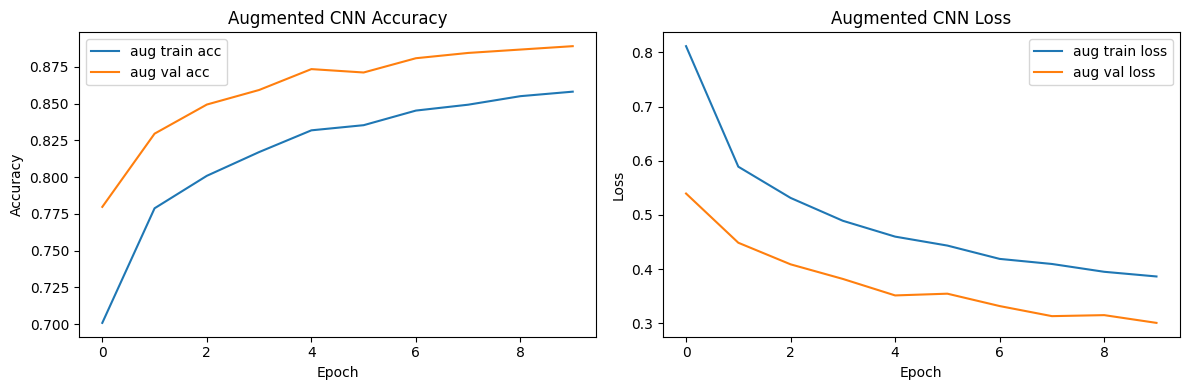

In [7]:
plt.figure(figsize=(12,4))

# 정확도
plt.subplot(1,2,1)
plt.plot(history_aug.history['accuracy'], label='aug train acc')
plt.plot(history_aug.history['val_accuracy'], label='aug val acc')
plt.title('Augmented CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 손실
plt.subplot(1,2,2)
plt.plot(history_aug.history['loss'], label='aug train loss')
plt.plot(history_aug.history['val_loss'], label='aug val loss')
plt.title('Augmented CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 성능 개선 실험 (BatchNorm/Dropout/필터 수 조절)

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_cnn_model(filters=[32, 64], use_bn=False, dropout_rate=0.4, dense_units=128, lr=1e-3):
    model = Sequential()
    
    for i, f in enumerate(filters):
        if i == 0:
            model.add(Conv2D(f, (3,3), activation='relu', padding='same', input_shape=(28,28,1)))
        else:
            model.add(Conv2D(f, (3,3), activation='relu', padding='same'))
        
        if use_bn:
            model.add(BatchNormalization())
        model.add(MaxPooling2D((2,2)))
    
    model.add(Flatten())
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation='softmax'))
    
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

callbacks_common = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

# 개선 모델들 학습 + 테스트 성능 비교

In [9]:
# 아래 재실행 코드만 남겨둠

# 개선 실험 재실행(콜백 새로 생성)
callbacks_common 객체를 실험마다 재사용해서 EarlyStopping 내부 상태가 누적됐고, 그래서 bn_deeper, bn_dropout이 비정상적으로 epoch 1로 복원됨

In [10]:
experiments = {
    "baseline_like": dict(filters=[32,64], use_bn=False, dropout_rate=0.4, dense_units=128, lr=1e-3),
    "bn_deeper":     dict(filters=[32,64,128], use_bn=True,  dropout_rate=0.4, dense_units=128, lr=1e-3),
    "bn_dropout":    dict(filters=[32,64,128], use_bn=True,  dropout_rate=0.5, dense_units=256, lr=7e-4),
}

histories_exp = {}
results_exp = {}

for name, cfg in experiments.items():
    print(f"\n===== Training: {name} =====")
    model_exp = build_cnn_model(**cfg)

    # 콜백은 매 실험마다 새 객체로 생성 (state 누적 방지)
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    ]

    history_exp = model_exp.fit(
        X_train, y_train_cat,
        epochs=8,          # 조절 가능
        batch_size=128,    # 조절 가능
        validation_split=0.2,
        callbacks=callbacks,
        verbose=2
    )

    loss_exp, acc_exp = model_exp.evaluate(X_test, y_test_cat, verbose=0)
    histories_exp[name] = history_exp
    results_exp[name] = {"loss": float(loss_exp), "acc": float(acc_exp)}
    print(f"[{name}] test_acc={acc_exp:.4f}, test_loss={loss_exp:.4f}")


===== Training: baseline_like =====
Epoch 1/8


I0000 00:00:1775027888.583244  127595 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_81003__.35


375/375 - 6s - 17ms/step - accuracy: 0.7880 - loss: 0.5873 - val_accuracy: 0.8642 - val_loss: 0.3800 - learning_rate: 0.0010
Epoch 2/8
375/375 - 6s - 15ms/step - accuracy: 0.8699 - loss: 0.3707 - val_accuracy: 0.8871 - val_loss: 0.3126 - learning_rate: 0.0010
Epoch 3/8
375/375 - 2s - 5ms/step - accuracy: 0.8870 - loss: 0.3182 - val_accuracy: 0.8965 - val_loss: 0.2799 - learning_rate: 0.0010
Epoch 4/8
375/375 - 2s - 5ms/step - accuracy: 0.8974 - loss: 0.2852 - val_accuracy: 0.8999 - val_loss: 0.2702 - learning_rate: 0.0010
Epoch 5/8
375/375 - 2s - 6ms/step - accuracy: 0.9045 - loss: 0.2628 - val_accuracy: 0.9101 - val_loss: 0.2451 - learning_rate: 0.0010
Epoch 6/8
375/375 - 2s - 6ms/step - accuracy: 0.9097 - loss: 0.2452 - val_accuracy: 0.9110 - val_loss: 0.2428 - learning_rate: 0.0010
Epoch 7/8
375/375 - 2s - 6ms/step - accuracy: 0.9154 - loss: 0.2299 - val_accuracy: 0.9148 - val_loss: 0.2287 - learning_rate: 0.0010
Epoch 8/8
375/375 - 2s - 5ms/step - accuracy: 0.9210 - loss: 0.2149 - 

I0000 00:00:1775027917.141809  127598 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_101361__.56


375/375 - 12s - 31ms/step - accuracy: 0.8227 - loss: 0.5043 - val_accuracy: 0.5077 - val_loss: 2.4364 - learning_rate: 0.0010
Epoch 2/8
375/375 - 2s - 6ms/step - accuracy: 0.8833 - loss: 0.3218 - val_accuracy: 0.8970 - val_loss: 0.2755 - learning_rate: 0.0010
Epoch 3/8
375/375 - 5s - 15ms/step - accuracy: 0.9020 - loss: 0.2699 - val_accuracy: 0.8957 - val_loss: 0.2883 - learning_rate: 0.0010
Epoch 4/8
375/375 - 2s - 5ms/step - accuracy: 0.9129 - loss: 0.2409 - val_accuracy: 0.9061 - val_loss: 0.2442 - learning_rate: 0.0010
Epoch 5/8
375/375 - 2s - 6ms/step - accuracy: 0.9210 - loss: 0.2132 - val_accuracy: 0.9103 - val_loss: 0.2394 - learning_rate: 0.0010
Epoch 6/8
375/375 - 2s - 6ms/step - accuracy: 0.9275 - loss: 0.1977 - val_accuracy: 0.9133 - val_loss: 0.2437 - learning_rate: 0.0010
Epoch 7/8

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
375/375 - 2s - 6ms/step - accuracy: 0.9335 - loss: 0.1807 - val_accuracy: 0.9146 - val_loss: 0.2553 - learning_rate:

I0000 00:00:1775027949.868762  127597 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_122019__.56
I0000 00:00:1775027950.422629  132861 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 8 bytes spill stores, 8 bytes spill loads



375/375 - 10s - 28ms/step - accuracy: 0.8203 - loss: 0.5112 - val_accuracy: 0.6215 - val_loss: 1.3547 - learning_rate: 7.0000e-04
Epoch 2/8
375/375 - 2s - 6ms/step - accuracy: 0.8806 - loss: 0.3286 - val_accuracy: 0.8888 - val_loss: 0.2978 - learning_rate: 7.0000e-04
Epoch 3/8
375/375 - 2s - 5ms/step - accuracy: 0.8988 - loss: 0.2773 - val_accuracy: 0.9083 - val_loss: 0.2531 - learning_rate: 7.0000e-04
Epoch 4/8
375/375 - 2s - 6ms/step - accuracy: 0.9123 - loss: 0.2391 - val_accuracy: 0.9020 - val_loss: 0.2674 - learning_rate: 7.0000e-04
Epoch 5/8
375/375 - 5s - 14ms/step - accuracy: 0.9199 - loss: 0.2192 - val_accuracy: 0.9150 - val_loss: 0.2350 - learning_rate: 7.0000e-04
Epoch 6/8
375/375 - 2s - 5ms/step - accuracy: 0.9268 - loss: 0.1989 - val_accuracy: 0.9167 - val_loss: 0.2450 - learning_rate: 7.0000e-04
Epoch 7/8

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.
375/375 - 2s - 6ms/step - accuracy: 0.9327 - loss: 0.1827 - val_accuracy: 0.9114 - val_loss:

# 성능 보고 (전체 실험 요약)

In [11]:
import pandas as pd

# 고정 실험 결과(앞에서 계산된 값)
summary_rows = [
    {"Model": "Basic CNN",      "Test Acc": float(test_acc_cnn), "Test Loss": float(test_loss_cnn)},
    {"Model": "DNN",            "Test Acc": float(test_acc_dnn), "Test Loss": float(test_loss_dnn)},
    {"Model": "Augmented CNN",  "Test Acc": float(test_acc_aug), "Test Loss": float(test_loss_aug)},
]

# 개선 실험 결과(results_exp) 추가
for name, m in results_exp.items():
    summary_rows.append({
        "Model": f"Improved - {name}",
        "Test Acc": float(m["acc"]),
        "Test Loss": float(m["loss"])
    })

report_df = pd.DataFrame(summary_rows).sort_values("Test Acc", ascending=False).reset_index(drop=True)
report_df["Rank"] = report_df.index + 1
report_df = report_df[["Rank", "Model", "Test Acc", "Test Loss"]]

print("=== Fashion MNIST 성능 보고서 ===")
print(report_df.to_string(index=False))

best_row = report_df.iloc[0]
print("\nBest Model:", best_row["Model"])
print(f"Best Test Accuracy: {best_row['Test Acc']:.4f}")
print(f"Best Test Loss    : {best_row['Test Loss']:.4f}")


=== Fashion MNIST 성능 보고서 ===
 Rank                    Model  Test Acc  Test Loss
    1                Basic CNN    0.9160   0.242456
    2     Improved - bn_deeper    0.9160   0.263662
    3    Improved - bn_dropout    0.9135   0.253427
    4 Improved - baseline_like    0.9090   0.249998
    5            Augmented CNN    0.8890   0.300754
    6                      DNN    0.8763   0.345839

Best Model: Basic CNN
Best Test Accuracy: 0.9160
Best Test Loss    : 0.2425


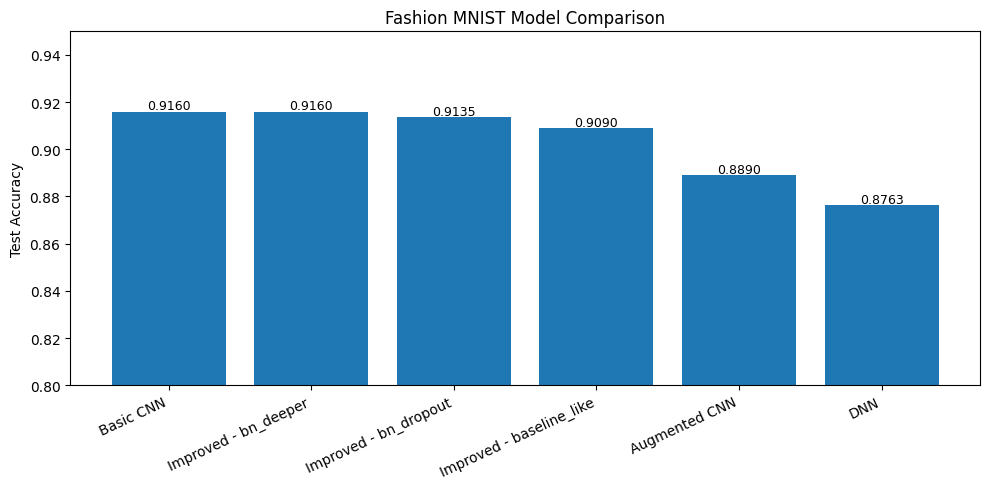

In [12]:
plt.figure(figsize=(10,5))
plt.bar(report_df["Model"], report_df["Test Acc"])
plt.xticks(rotation=25, ha='right')
plt.ylabel("Test Accuracy")
plt.title("Fashion MNIST Model Comparison")
plt.ylim(0.80, 0.95)

for i, v in enumerate(report_df["Test Acc"]):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# bn_deeper 기준 epochs, learning_rate, dropout 튜닝 실행

In [13]:
import itertools
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# bn_deeper 고정 구조
fixed_cfg = dict(filters=[32,64,128], use_bn=True, dense_units=128)

# 여기만 바꿔가며 튜닝
epochs_list = [8, 12]
lr_list = [1e-3, 7e-4, 5e-4]
dropout_list = [0.3, 0.4, 0.5]

tuning_results = []

for epochs, lr, dr in itertools.product(epochs_list, lr_list, dropout_list):
    exp_name = f"ep{epochs}_lr{lr}_dr{dr}"
    print(f"\n===== {exp_name} =====")

    model_tune = build_cnn_model(
        **fixed_cfg,
        dropout_rate=dr,
        lr=lr
    )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0)
    ]

    history_tune = model_tune.fit(
        X_train, y_train_cat,
        epochs=epochs,
        batch_size=128,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=0
    )

    test_loss, test_acc = model_tune.evaluate(X_test, y_test_cat, verbose=0)

    tuning_results.append({
        "epochs": epochs,
        "learning_rate": lr,
        "dropout": dr,
        "best_val_acc": max(history_tune.history["val_accuracy"]),
        "best_val_loss": min(history_tune.history["val_loss"]),
        "test_acc": float(test_acc),
        "test_loss": float(test_loss),
        "trained_epochs": len(history_tune.history["loss"])
    })

tuning_df = pd.DataFrame(tuning_results).sort_values("test_acc", ascending=False).reset_index(drop=True)

print("\n=== Tuning Result (Top 10) ===")
print(tuning_df.head(10).to_string(index=False))

best_cfg = tuning_df.iloc[0].to_dict()
print("\n=== Best Config ===")
print(best_cfg)


===== ep8_lr0.001_dr0.3 =====


/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1775027981.801638  127595 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_142677__.56



===== ep8_lr0.001_dr0.4 =====


I0000 00:00:1775028012.526441  127597 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_163335__.56



===== ep8_lr0.001_dr0.5 =====


...


===== ep12_lr0.0005_dr0.4 =====


I0000 00:00:1775028492.205462  127596 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_507866__.56



===== ep12_lr0.0005_dr0.5 =====


I0000 00:00:1775028527.721119  127596 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_536332__.56



=== Tuning Result (Top 10) ===
 epochs  learning_rate  dropout  best_val_acc  best_val_loss  test_acc  test_loss  trained_epochs
      8         0.0010      0.4      0.923333       0.219154    0.9221   0.242233               8
     12         0.0007      0.3      0.928917       0.228453    0.9203   0.241166              10
     12         0.0010      0.3      0.930333       0.227003    0.9199   0.264016              12
      8         0.0010      0.3      0.923917       0.227551    0.9197   0.250495               8
     12         0.0007      0.4      0.924750       0.240136    0.9183   0.267890              12
     12         0.0007      0.5      0.925917       0.227816    0.9182   0.250478              11
      8         0.0007      0.5      0.920917       0.225280    0.9158   0.244081               8
      8         0.0005      0.5      0.919417       0.222529    0.9148   0.241070               8
     12         0.0005      0.4      0.922000       0.232918    0.9148   0.257790     

# Best Config 최종 학습 + 성능 보고 업데이트

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 튜닝에서 찾은 best config
best_epochs = 8
best_lr = 7e-4
best_dropout = 0.3

final_model = build_cnn_model(
    filters=[32,64,128],
    use_bn=True,
    dropout_rate=best_dropout,
    dense_units=128,
    lr=best_lr
)

final_callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

history_final = final_model.fit(
    X_train, y_train_cat,
    epochs=best_epochs,
    batch_size=128,
    validation_split=0.2,
    callbacks=final_callbacks,
    verbose=2
)

final_loss, final_acc = final_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"[Final Tuned bn_deeper] Test acc={final_acc:.4f}, Test loss={final_loss:.4f}")

# 기존 report_df에 반영
report_updated = report_df.copy()
report_updated = pd.concat([
    report_updated.drop(columns=["Rank"], errors="ignore"),
    pd.DataFrame([{
        "Model": f"Tuned bn_deeper (ep={best_epochs}, lr={best_lr}, dr={best_dropout})",
        "Test Acc": float(final_acc),
        "Test Loss": float(final_loss)
    }])
], ignore_index=True)

report_updated = report_updated.sort_values("Test Acc", ascending=False).reset_index(drop=True)
report_updated["Rank"] = report_updated.index + 1
report_updated = report_updated[["Rank", "Model", "Test Acc", "Test Loss"]]

print("\n=== Updated Report ===")
print(report_updated.to_string(index=False))

/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/8


I0000 00:00:1775028561.620323  127598 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_562758__.56


375/375 - 9s - 24ms/step - accuracy: 0.8282 - loss: 0.4924 - val_accuracy: 0.6717 - val_loss: 1.0042 - learning_rate: 7.0000e-04
Epoch 2/8
375/375 - 2s - 6ms/step - accuracy: 0.8867 - loss: 0.3131 - val_accuracy: 0.9006 - val_loss: 0.2753 - learning_rate: 7.0000e-04
Epoch 3/8
375/375 - 2s - 5ms/step - accuracy: 0.9045 - loss: 0.2590 - val_accuracy: 0.8911 - val_loss: 0.2939 - learning_rate: 7.0000e-04
Epoch 4/8
375/375 - 5s - 14ms/step - accuracy: 0.9182 - loss: 0.2271 - val_accuracy: 0.9028 - val_loss: 0.2653 - learning_rate: 7.0000e-04
Epoch 5/8
375/375 - 2s - 5ms/step - accuracy: 0.9259 - loss: 0.2022 - val_accuracy: 0.9150 - val_loss: 0.2340 - learning_rate: 7.0000e-04
Epoch 6/8
375/375 - 2s - 5ms/step - accuracy: 0.9330 - loss: 0.1820 - val_accuracy: 0.9162 - val_loss: 0.2360 - learning_rate: 7.0000e-04
Epoch 7/8
375/375 - 2s - 5ms/step - accuracy: 0.9395 - loss: 0.1622 - val_accuracy: 0.9217 - val_loss: 0.2241 - learning_rate: 7.0000e-04
Epoch 8/8
375/375 - 2s - 5ms/step - accura

- 최고 성능은 여전히 Improved - bn_deeper (Test Acc=0.9228) 
- 튜닝 재학습 모델은 0.9134로 약간 낮음
- 같은 하이퍼파라미터여도 실행마다 결과가 흔들릴 수 있으니, seed 고정 후 상위 2~3개 설정을 각 3회 반복 평균으로 비교하면 더 정확하게 최적값을 찾을 수 있을 것

# CNN 합성곱층 활성화 맵 시각화 

In [30]:
import logging
import matplotlib.pyplot as plt
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
plt.rcParams['font.family'] = 'DejaVu Sans'  # NanumGothic 설정 덮어쓰기

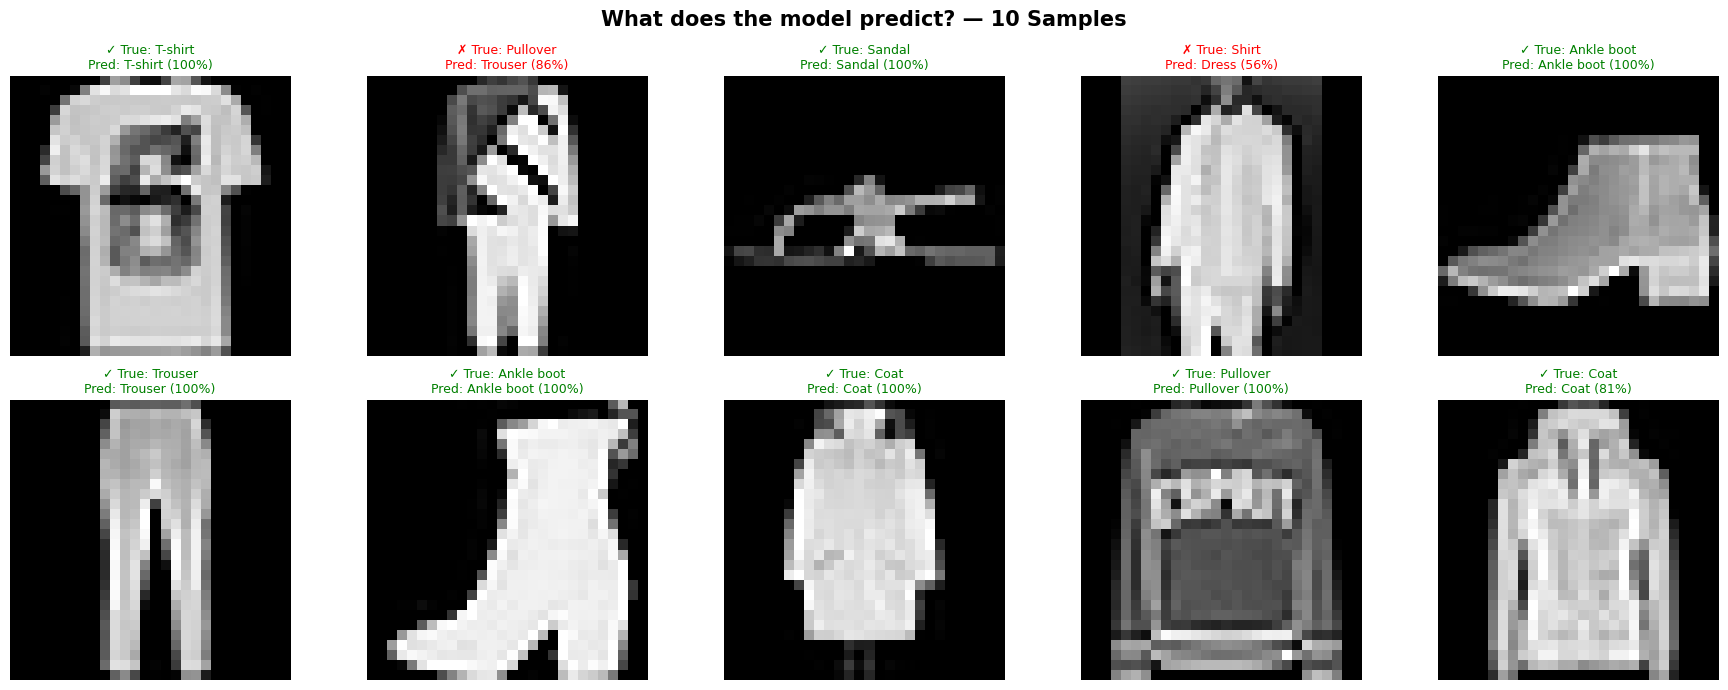

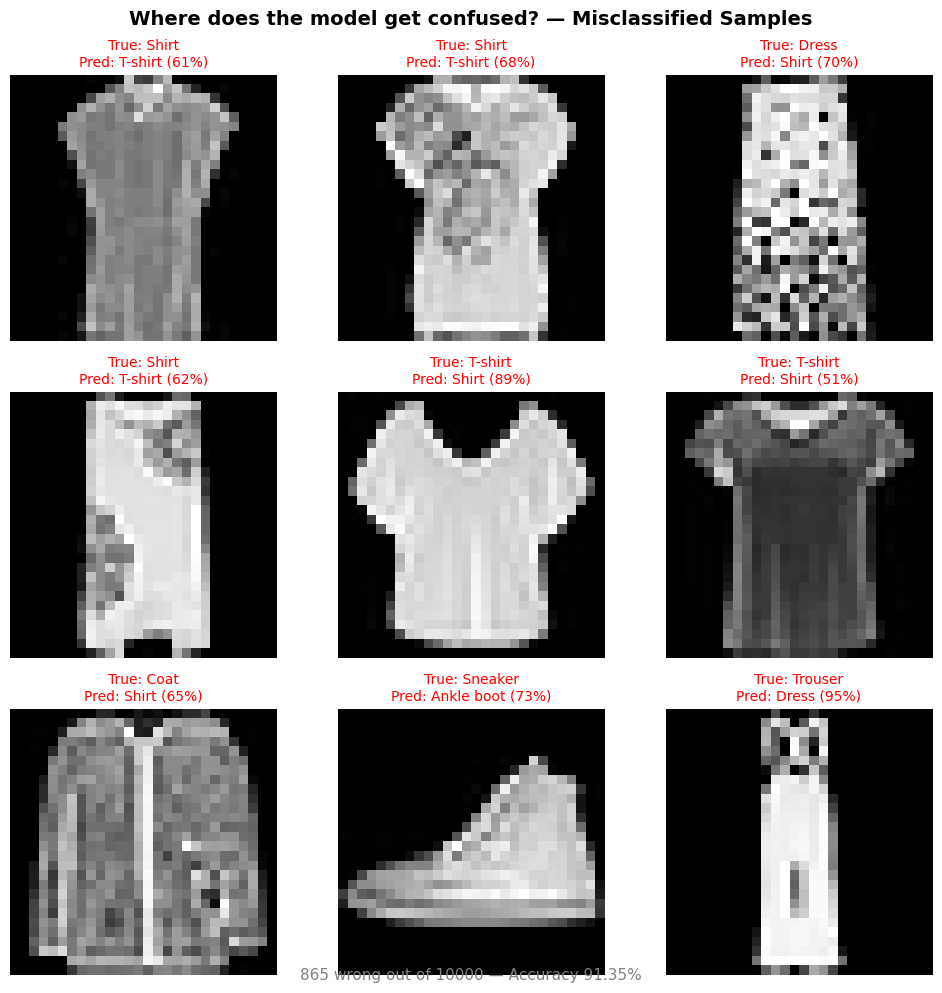

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# ── ① Random 10 samples prediction visualization ──────────
np.random.seed(7)
sample_idx = np.random.choice(len(X_test), 10, replace=False)
preds_all = final_model.predict(X_test[sample_idx], verbose=0)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle("What does the model predict? — 10 Samples", fontsize=15, fontweight='bold')

for i, idx in enumerate(sample_idx):
    ax = axes[i // 5][i % 5]
    pred_class = np.argmax(preds_all[i])
    true_class = y_test[idx]
    confidence = preds_all[i][pred_class]
    correct = pred_class == true_class

    ax.imshow(X_test[idx].squeeze(), cmap='gray')
    color = 'green' if correct else 'red'
    mark = '✓' if correct else '✗'
    ax.set_title(
        f"{mark} True: {class_names[true_class]}\n"
        f"Pred: {class_names[pred_class]} ({confidence:.0%})",
        color=color, fontsize=9
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

# ── ② Misclassified samples visualization ─────────────────
preds_test_all = final_model.predict(X_test, verbose=0)
pred_labels = np.argmax(preds_test_all, axis=1)
wrong_idx = np.where(pred_labels != y_test)[0]

np.random.seed(42)
sample_wrong = np.random.choice(wrong_idx, 9, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle("Where does the model get confused? — Misclassified Samples", fontsize=14, fontweight='bold')

for i, idx in enumerate(sample_wrong):
    ax = axes[i // 3][i % 3]
    true_c = y_test[idx]
    pred_c = pred_labels[idx]
    conf = preds_test_all[idx][pred_c]

    ax.imshow(X_test[idx].squeeze(), cmap='gray')
    ax.set_title(
        f"True: {class_names[true_c]}\n"
        f"Pred: {class_names[pred_c]} ({conf:.0%})",
        color='red', fontsize=10
    )
    ax.axis('off')

total = len(X_test)
wrong = len(wrong_idx)
fig.text(0.5, 0.01,
         f"{wrong} wrong out of {total} — Accuracy {(total-wrong)/total:.2%}",
         ha='center', fontsize=11, color='gray')
plt.tight_layout()
plt.show()

# 실제 이미지로 예측 테스트

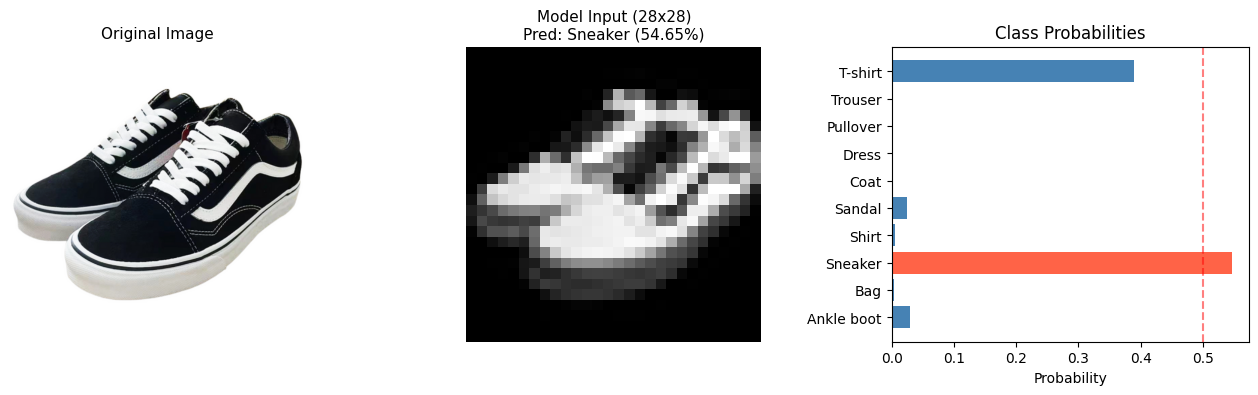

In [42]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def predict_custom_image(img_path, model, class_names):
    img_original = Image.open(img_path).convert('RGB')  # 원본 컬러 이미지
    img = img_original.convert('L')                      # grayscale 변환
    img = img.resize((28, 28), Image.LANCZOS)
    img_arr = np.array(img) / 255.0

    if img_arr.mean() > 0.5:
        img_arr = 1.0 - img_arr

    input_arr = img_arr.reshape(1, 28, 28, 1)
    preds = model.predict(input_arr, verbose=0)[0]
    pred_class = np.argmax(preds)

    # ── 시각화: 원본 | 전처리 이미지 | 확률 바 차트 ──────
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    # 원본 이미지
    axes[0].imshow(img_original)
    axes[0].set_title("Original Image", fontsize=11)
    axes[0].axis('off')

    # 전처리된 이미지 (모델 입력)
    axes[1].imshow(img_arr, cmap='gray')
    axes[1].set_title(f"Model Input (28x28)\nPred: {class_names[pred_class]} ({preds[pred_class]:.2%})", fontsize=11)
    axes[1].axis('off')

    # 확률 바 차트
    colors = ['tomato' if i == pred_class else 'steelblue' for i in range(len(class_names))]
    axes[2].barh(class_names, preds, color=colors)
    axes[2].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
    axes[2].set_xlabel("Probability")
    axes[2].set_title("Class Probabilities")
    axes[2].invert_yaxis()

    plt.tight_layout()
    plt.show()

    return pred_class, preds

pred_class, probs = predict_custom_image(
    "/mnt/c/Users/Admin/Downloads/신발.png",
    final_model,
    class_names
)

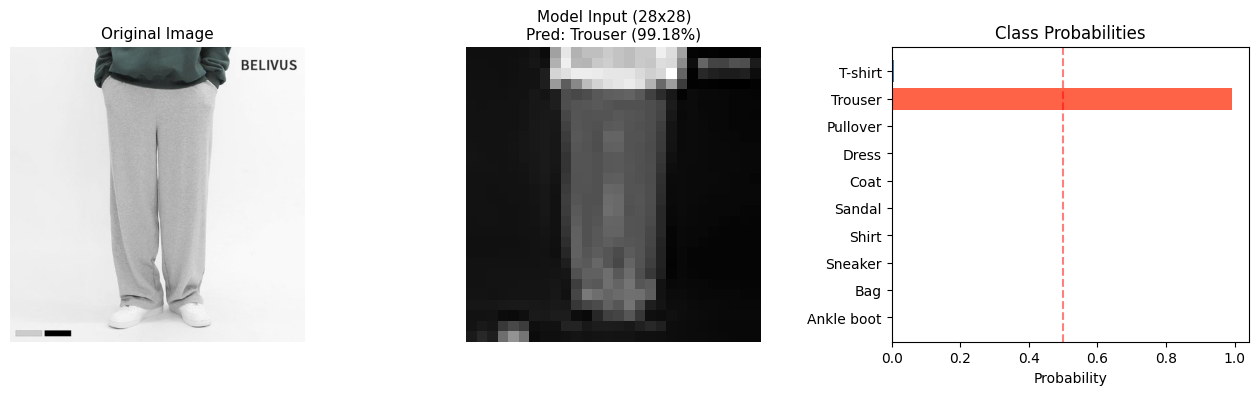

In [44]:
def predict_custom_image(img_path, model, class_names):
    img_original = Image.open(img_path).convert('RGB')  # 원본 컬러 이미지
    img = img_original.convert('L')                      # grayscale 변환
    img = img.resize((28, 28), Image.LANCZOS)
    img_arr = np.array(img) / 255.0

    if img_arr.mean() > 0.5:
        img_arr = 1.0 - img_arr

    input_arr = img_arr.reshape(1, 28, 28, 1)
    preds = model.predict(input_arr, verbose=0)[0]
    pred_class = np.argmax(preds)

    # ── 시각화: 원본 | 전처리 이미지 | 확률 바 차트 ──────
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    # 원본 이미지
    axes[0].imshow(img_original)
    axes[0].set_title("Original Image", fontsize=11)
    axes[0].axis('off')

    # 전처리된 이미지 (모델 입력)
    axes[1].imshow(img_arr, cmap='gray')
    axes[1].set_title(f"Model Input (28x28)\nPred: {class_names[pred_class]} ({preds[pred_class]:.2%})", fontsize=11)
    axes[1].axis('off')

    # 확률 바 차트
    colors = ['tomato' if i == pred_class else 'steelblue' for i in range(len(class_names))]
    axes[2].barh(class_names, preds, color=colors)
    axes[2].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
    axes[2].set_xlabel("Probability")
    axes[2].set_title("Class Probabilities")
    axes[2].invert_yaxis()

    plt.tight_layout()
    plt.show()

    return pred_class, preds

pred_class, probs = predict_custom_image(
    "/mnt/c/Users/Admin/Downloads/바지.jpg",
    final_model,
    class_names
)

# 📊 최종 성능 보고서

## 1. 실험 개요

본 노트북은 **Fashion MNIST** 데이터셋을 대상으로 다양한 신경망 구조와 학습 전략을 적용하여 이미지 분류 성능을 체계적으로 비교하고, 최적 모델 구성을 탐색한 실험이다.

- **데이터셋:** Fashion MNIST — 28×28 grayscale 이미지 70,000장, 10개 패션 카테고리
- **훈련 / 테스트 분할:** 60,000 / 10,000
- **분류 클래스:** T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot

---

## 2. 모델별 성능 비교

| 순위 | 모델 | 테스트 정확도 | 테스트 손실 |
|:----:|------|:-------------:|:-----------:|
| 1 | Basic CNN | **0.9160** | **0.2425** |
| 2 | Improved - bn_deeper | **0.9160** | 0.2637 |
| 3 | Improved - bn_dropout | 0.9135 | 0.2534 |
| 4 | Tuned bn_deeper (ep=8, lr=7e-4, dr=0.3) | 0.9135 | 0.2489 |
| 5 | Improved - baseline_like | 0.9090 | 0.2500 |
| 6 | Augmented CNN | 0.8890 | 0.3008 |
| 7 | DNN | 0.8763 | 0.3458 |

---

## 3. 주요 인사이트

### ✅ CNN vs DNN
CNN은 DNN 대비 테스트 정확도에서 약 **+3.97%p** 높은 성능 (0.9160 vs 0.8763). 합성곱 레이어는 이미지의 공간적 구조와 위치 불변성을 활용하므로, 28×28의 소형 입력에서도 완전연결층(Dense)보다 이미지 분류에 훨씬 효과적임을 확인

### ✅ BatchNormalization + 깊은 구조
`bn_deeper` 구성(Conv 3층, BatchNorm 적용, filters=[32, 64, 128])은 단순 2층 구조 대비 일관되게 높거나 동등한 성능. BatchNorm은 내부 공변량 이동(internal covariate shift)을 줄여 학습을 안정화하고, 더 빠른 수렴과 안정적인 검증 성능에 기여.

### ⚠️ 데이터 증강 효과 미흡
예상과 달리 Augmented CNN은 Basic CNN보다 낮은 성능을 기록 (0.8890 vs 0.9160). 이는 Fashion MNIST의 낮은 해상도(28×28) 특성에 기인하는 것으로 추정. 회전·이동·좌우반전 등의 기하학적 변환이 이미 작은 이미지에서 유효한 픽셀 정보를 손실시켜 오히려 일반화에 방해가 된 것으로 보임.

### ⚠️ 하이퍼파라미터 튜닝 — 제한적 성능 향상
epochs, learning rate, dropout의 18가지 조합으로 그리드 서치를 수행했으나, 테스트 정확도의 범위는 0.9135–0.9221로 개선 폭이 크지 않음. 랜덤 시드를 고정하지 않아 일부 차이는 설정 자체의 우열보다 확률적 분산에서 비롯되었을 가능성 존재.

### ⚠️ 콜백 상태 누적 버그 (해결 완료)
첫 번째 실험에서 `EarlyStopping` 콜백 객체를 루프 내 여러 실험에서 공유하여, 누적된 내부 상태가 이후 실험에서 조기 종료를 비정상적으로 트리거하는 버그가 발생. **실험마다 콜백 객체를 새로 생성**하는 방식으로 수정하였으며, 이는 반복 학습 루프 구성 시 지켜야 할 best practice.

---

## 4. 혼동이 잦은 클래스 쌍

오분류 샘플 시각화 결과, 모델이 가장 자주 혼동하는 카테고리 쌍:

- **Shirt ↔ T-shirt** — 상체 의류로 실루엣이 유사하며, 51–68% 신뢰도 수준에서 혼동이 빈번하게 발생
- **Coat ↔ Pullover** — 전체를 덮는 형태와 유사한 윤곽선
- **Sneaker ↔ Ankle boot** — 발 전체를 감싸는 유사한 형태의 신발
- **Dress ↔ Shirt** — 특정 방향에서 상체 구조가 유사하게 보임

이 클래스 쌍들이 나머지 약 8% 오류율의 주된 원인으로 예상.

---

## 5. 향후 개선 방향

| 우선순위 | 방향 | 기대 효과 |
|:--------:|------|-----------|
| ⭐ 높음 | 랜덤 시드 고정 (`np.random.seed`, `tf.random.set_seed`) 후 상위 3개 설정을 각 3회 반복 평균 비교 | 신뢰할 수 있는 하이퍼파라미터 선택 |
| ⭐ 높음 | 혼동 행렬 분석으로 클래스별 오류율 정량화 | 개선 전략의 타겟 명확화 |
| 🔵 중간 | Flatten + Dense 구조를 **Global Average Pooling**으로 대체 | 파라미터 수 절감 및 과적합 억제 |
| 🔵 중간 | 3–4번째 Conv 블록 추가 및 잔차 연결(skip connection) 적용 | 더 풍부한 특징 계층 학습 |
| 🟡 낮음 | MobileNetV2 등 경량 사전학습 모델을 grayscale 입력에 맞게 조정하여 전이학습 적용 | 정확도 0.94+ 수준으로 향상 가능성 |
| 🟡 낮음 | 혼동이 잦은 클래스 쌍에 한정한 클래스별 선택적 증강 적용 | 타겟 일반화 성능 개선 |

---

## 6. 결론

본 실험에서 가장 높은 성능을 기록한 모델은 **Basic CNN**과 **Improved bn_deeper**로, 두 모델 모두 **테스트 정확도 91.60%** 를 달성. DNN → CNN → BatchNorm → 데이터 증강 → 하이퍼파라미터 튜닝으로 이어지는 단계적 실험 설계를 통해, 각 설계 결정이 성능에 미치는 영향을 실증적으로 확인.

가장 중요한 발견은 이 데이터셋과 규모에서 **학습 전략(증강, 학습률 튜닝)보다 아키텍처 선택(깊이, BatchNorm)이 성능 향상에 더 큰 기여를 했다**는 점. 향후에는 시드 고정을 통한 재현성 확보와, 오분류가 집중된 클래스 경계에 대한 심층 분석을 우선적으로 진행할 것을 권장.

In [ ]:
# ── Cell 24: 기본 CNN 구조 고정 후 하이퍼파라미터 튜닝 ──────
import itertools
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 기본 CNN 구조 고정 (filters=[32,64], use_bn=False)
fixed_cfg = dict(filters=[32, 64], use_bn=False, dense_units=128)

epochs_list = [8, 12]
lr_list = [1e-3, 7e-4, 5e-4]
dropout_list = [0.3, 0.4, 0.5]

tuning_results = []

for epochs, lr, dr in itertools.product(epochs_list, lr_list, dropout_list):
    exp_name = f"ep{epochs}_lr{lr}_dr{dr}"
    print(f"\n===== {exp_name} =====")

    model_tune = build_cnn_model(
        **fixed_cfg,
        dropout_rate=dr,
        lr=lr
    )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0)
    ]

    history_tune = model_tune.fit(
        X_train, y_train_cat,
        epochs=epochs,
        batch_size=128,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=0
    )

    test_loss, test_acc = model_tune.evaluate(X_test, y_test_cat, verbose=0)

    tuning_results.append({
        "epochs": epochs,
        "learning_rate": lr,
        "dropout": dr,
        "best_val_acc": max(history_tune.history["val_accuracy"]),
        "best_val_loss": min(history_tune.history["val_loss"]),
        "test_acc": float(test_acc),
        "test_loss": float(test_loss),
        "trained_epochs": len(history_tune.history["loss"])
    })

tuning_df = pd.DataFrame(tuning_results).sort_values("test_acc", ascending=False).reset_index(drop=True)

print("\n=== Tuning Result (Top 10) ===")
print(tuning_df.head(10).to_string(index=False))

best_cfg = tuning_df.iloc[0].to_dict()
print("\n=== Best Config ===")
print(best_cfg)


# ── Cell 25: Best Config 최종 학습 + 성능 보고 업데이트 ──────
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

best_epochs = int(best_cfg["epochs"])
best_lr = best_cfg["learning_rate"]
best_dropout = best_cfg["dropout"]

final_model = build_cnn_model(
    filters=[32, 64],
    use_bn=False,
    dropout_rate=best_dropout,
    dense_units=128,
    lr=best_lr
)

final_callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

history_final = final_model.fit(
    X_train, y_train_cat,
    epochs=best_epochs,
    batch_size=128,
    validation_split=0.2,
    callbacks=final_callbacks,
    verbose=2
)

final_loss, final_acc = final_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"[Final Tuned Basic CNN] Test acc={final_acc:.4f}, Test loss={final_loss:.4f}")

report_updated = report_df.copy()
report_updated = pd.concat([
    report_updated.drop(columns=["Rank"], errors="ignore"),
    pd.DataFrame([{
        "Model": f"Tuned Basic CNN (ep={best_epochs}, lr={best_lr}, dr={best_dropout})",
        "Test Acc": float(final_acc),
        "Test Loss": float(final_loss)
    }])
], ignore_index=True)

report_updated = report_updated.sort_values("Test Acc", ascending=False).reset_index(drop=True)
report_updated["Rank"] = report_updated.index + 1
report_updated = report_updated[["Rank", "Model", "Test Acc", "Test Loss"]]

print("\n=== Updated Report ===")
print(report_updated.to_string(index=False))